Step 1 — Import Library

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Step 2 — Load & Resize Image

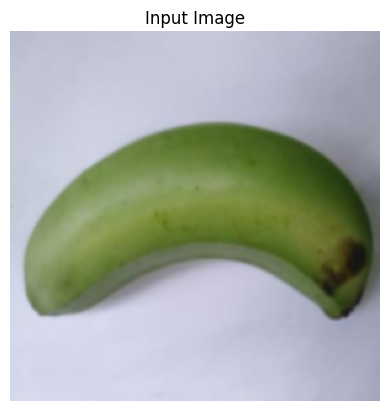

In [ ]:
img = cv2.imread('pisang.jpg')

if img is None:
    print("Error: Image 'pisang.jpg' not found or could not be loaded. Please ensure the image file is in the correct directory.")
else:
    img = cv2.resize(img, (300, 300))
    # blur biar noise hilang
    img = cv2.GaussianBlur(img, (5,5), 0)

    # convert ke RGB untuk display
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img_rgb)
    plt.title("Input Image")
    plt.axis('off')

In [ ]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

In [ ]:
# Hijau (mentah)
lower_green = np.array([35, 50, 50])
upper_green = np.array([85, 255, 255])

# Kuning (matang)
lower_yellow = np.array([20, 100, 100])
upper_yellow = np.array([35, 255, 255])

# Coklat (busuk) → tricky, biasanya low V
lower_brown = np.array([10, 100, 20])
upper_brown = np.array([20, 255, 200])

In [ ]:
mask_green = cv2.inRange(hsv, lower_green, upper_green)
mask_yellow = cv2.inRange(hsv, lower_yellow, upper_yellow)
mask_brown = cv2.inRange(hsv, lower_brown, upper_brown)

In [ ]:
green_pixels = np.sum(mask_green > 0)
yellow_pixels = np.sum(mask_yellow > 0)
brown_pixels = np.sum(mask_brown > 0)

total = green_pixels + yellow_pixels + brown_pixels

print("Green:", green_pixels)
print("Yellow:", yellow_pixels)
print("Brown:", brown_pixels)

Green: 26937
Yellow: 1317
Brown: 78


In [ ]:
if green_pixels > yellow_pixels and green_pixels > brown_pixels:
    result = "Mentah"
elif yellow_pixels > green_pixels and yellow_pixels > brown_pixels:
    result = "Matang"
elif brown_pixels > yellow_pixels:
    result = "Busuk"
else:
    result = "Setengah Matang"

print("Hasil:", result)

Hasil: Mentah


Text(0.5, 1.0, 'Brown')

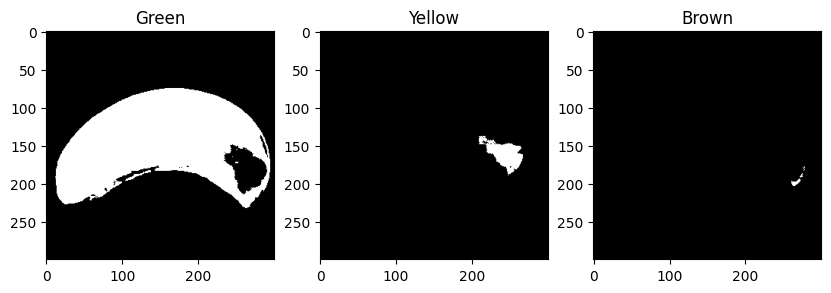

In [ ]:
plt.figure(figsize=(10,3))

plt.subplot(1,3,1)
plt.imshow(mask_green, cmap='gray')
plt.title("Green")

plt.subplot(1,3,2)
plt.imshow(mask_yellow, cmap='gray')
plt.title("Yellow")

plt.subplot(1,3,3)
plt.imshow(mask_brown, cmap='gray')
plt.title("Brown")